# Sesión 2: Cálculo aplicado, Regresión OLS, Probabilidad e Inferencia

**Objetivo de la sesión:** que el estudiante entienda y pueda reproducir en código la deducción matricial del estimador OLS, y que pueda cuantificar la incertidumbre asociada a los coeficientes estimados (errores estándar, intervalos de confianza, pruebas de hipótesis).



In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

sns.set_style("whitegrid")
%matplotlib inline

# Bloque 1: Cálculo condensado (hacia OLS)

## Derivada: la pendiente de una función

La derivada de una función $f(x)$ en un punto mide qué tan rápido cambia $f$ cuando $x$ cambia. Geométricamente es la pendiente de la recta tangente.

Para funciones simples usamos reglas conocidas, por ejemplo:

$$
f(x) = x^2 \quad \Rightarrow \quad f'(x) = 2x
$$

Lo importante para nosotros: **en un mínimo (o máximo) de una función suave, la derivada vale cero.**

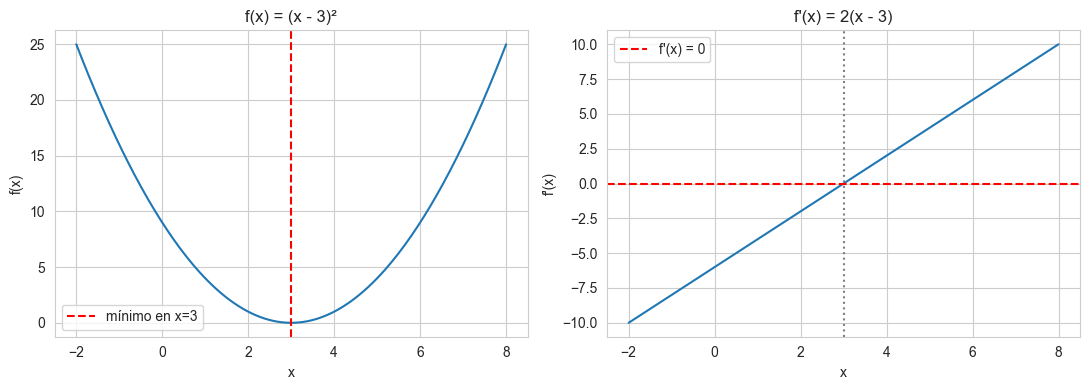

In [32]:
# Ejemplo numérico: f(x) = (x - 3)^2 tiene su mínimo en x = 3
x = np.linspace(-2, 8, 200)
f = (x - 3)**2
df = 2 * (x - 3)  # derivada

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x, f)
axes[0].axvline(3, color="red", linestyle="--", label="mínimo en x=3")
axes[0].set_title("f(x) = (x - 3)²")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].legend()

axes[1].plot(x, df)
axes[1].axhline(0, color="red", linestyle="--", label="f'(x) = 0")
axes[1].axvline(3, color="gray", linestyle=":")
axes[1].set_title("f'(x) = 2(x - 3)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("f'(x)")
axes[1].legend()

plt.tight_layout()
plt.show()

La derivada se anula exactamente donde $f$ alcanza su mínimo. Esta observación —**condición de primer orden**— es la idea central que vamos a extender a varias dimensiones para llegar a OLS.

## Regla de la cadena

Cuando una función está compuesta por otra, $f(g(x))$, su derivada es:

$$
\frac{d}{dx}f(g(x)) = f'(g(x))\cdot g'(x)
$$

La usaremos implícitamente al derivar expresiones cuadráticas que contienen productos matriciales, como $(\mathbf{y}-X\boldsymbol{\beta})^T(\mathbf{y}-X\boldsymbol{\beta})$.

## Gradiente: la derivada en varias dimensiones

Cuando la función depende de varias variables, $f(\beta_0, \beta_1, \dots)$, ya no hay una sola derivada sino un **vector de derivadas parciales**, llamado gradiente:

$$
\nabla f(\boldsymbol{\beta}) =
\begin{bmatrix}
\partial f/\partial \beta_0 \\
\partial f/\partial \beta_1 \\
\vdots
\end{bmatrix}
$$

La condición de primer orden en varias dimensiones es la misma idea: **en el mínimo, el gradiente es el vector cero.**

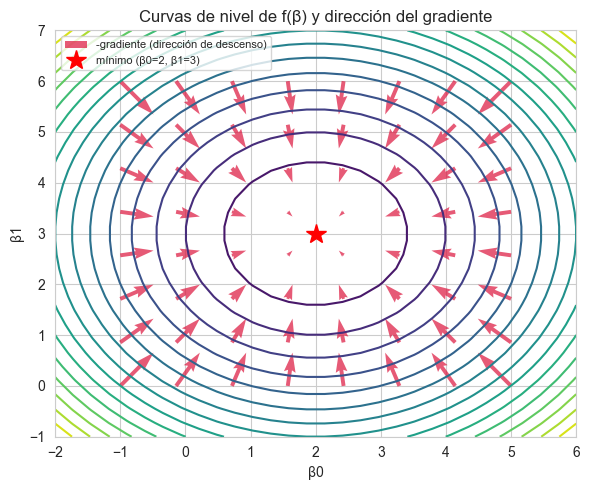

In [33]:
# Visualizacion del gradiente en 2D: f(b0, b1) = (b0-2)^2 + (b1-3)^2, minimo en (2, 3)
b0 = np.linspace(-2, 6, 30)
b1 = np.linspace(-1, 7, 30)
B0, B1 = np.meshgrid(b0, b1)
F = (B0 - 2)**2 + (B1 - 3)**2

# gradiente analitico: df/db0 = 2(b0-2), df/db1 = 2(b1-3)
b0_q = np.linspace(-1, 5, 8)
b1_q = np.linspace(0, 6, 8)
B0q, B1q = np.meshgrid(b0_q, b1_q)
dF0 = 2 * (B0q - 2)
dF1 = 2 * (B1q - 3)

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contour(B0, B1, F, levels=15, cmap="viridis")
ax.quiver(B0q, B1q, -dF0, -dF1, color="crimson", alpha=0.7, label="-gradiente (dirección de descenso)")
ax.plot(2, 3, "r*", markersize=15, label="mínimo (β0=2, β1=3)")
ax.set_xlabel("β0"); ax.set_ylabel("β1")
ax.set_title("Curvas de nivel de f(β) y dirección del gradiente")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Las flechas apuntan en la dirección de **mayor descenso**, y todas convergen hacia el mínimo donde el gradiente es cero. Esta es exactamente la lógica detrás de la deducción de OLS.

## De la función de pérdida a la ecuación normal

En regresión lineal buscamos el vector $\boldsymbol{\beta}$ que minimiza la suma de errores al cuadrado:

$$
\min_{\boldsymbol{\beta}} \; \|\mathbf{y} - X\boldsymbol{\beta}\|^2 = (\mathbf{y}-X\boldsymbol{\beta})^T(\mathbf{y}-X\boldsymbol{\beta})
$$

Aplicando la condición de primer orden (derivar respecto a $\boldsymbol{\beta}$ e igualar a cero):

$$
\nabla_{\boldsymbol{\beta}} \; (\mathbf{y}-X\boldsymbol{\beta})^T(\mathbf{y}-X\boldsymbol{\beta}) = -2X^T(\mathbf{y}-X\boldsymbol{\beta}) = \mathbf{0}
$$

Despejando:

$$
X^TX\boldsymbol{\beta} = X^T\mathbf{y} \qquad \text{(ecuación normal)}
$$

Y como vimos en la sesión anterior, si $X^TX$ es definida positiva (invertible):

$$
\hat{\boldsymbol{\beta}} = (X^TX)^{-1}X^T\mathbf{y}
$$


In [34]:
# Comprobación numérica: en la solución óptima, el gradiente de la pérdida es (numéricamente) cero
np.random.seed(42)
X_demo = np.column_stack([np.ones(5), np.array([1, 2, 3, 4, 5])])
y_demo = np.array([2.1, 3.9, 6.2, 7.8, 10.1])

beta_hat_demo = np.linalg.inv(X_demo.T @ X_demo) @ X_demo.T @ y_demo
gradiente = -2 * X_demo.T @ (y_demo - X_demo @ beta_hat_demo)

print("β̂ =", beta_hat_demo)
print("Gradiente en β̂ (debería ser ≈ 0):", np.round(gradiente, 10))

β̂ = [0.05 1.99]
Gradiente en β̂ (debería ser ≈ 0): [0. 0.]


# Bloque 2: Laboratorio — Regresión OLS aplicada

Vamos a aplicar la fórmula $\hat{\boldsymbol{\beta}} = (X^TX)^{-1}X^T\mathbf{y}$ a un dataset real: ventas semanales de tiendas, con variables como temperatura, precio del combustible y desempleo. Este mismo modelo se retomará en el bloque de inferencia para cuantificar la incertidumbre de los coeficientes.

In [35]:
datos = pd.read_csv("sales.csv")
datos = datos.drop(columns=["Unnamed: 0"])
print(datos.shape)
datos.head()

(10774, 9)


,store,type,department,date,weekly_sales,is_holiday,temperature_c,fuel_price_usd_per_l,unemployment
0,1,A,1,2010-02-05,24924.50,False,5.727778,0.679451,8.106
1,1,A,1,2010-03-05,21827.90,False,8.055556,0.693452,8.106
2,1,A,1,2010-04-02,57258.43,False,16.816667,0.718284,7.808
3,1,A,1,2010-05-07,17413.94,False,22.527778,0.748928,7.808
4,1,A,1,2010-06-04,17558.09,False,27.050000,0.714586,7.808


In [36]:
datos.describe()

,store,department,weekly_sales,temperature_c,fuel_price_usd_per_l,unemployment
count,10774.000000,10774.000000,10774.000000,10774.000000,10774.000000,10774.000000
mean,15.441897,45.218118,23843.950149,15.731978,0.749746,8.082009
std,11.534511,29.867779,30220.387557,9.922446,0.059494,0.624355
min,1.000000,1.000000,-1098.000000,-8.366667,0.664129,3.879000
25%,4.000000,20.000000,3867.115000,7.583333,0.708246,7.795000
50%,13.000000,40.000000,12049.065000,16.966667,0.743381,8.099000
75%,20.000000,72.000000,32349.850000,24.166667,0.781421,8.360000
max,39.000000,99.000000,293966.050000,33.827778,1.107674,9.765000


## Variable respuesta y predictoras

- **Respuesta ($y$):** `weekly_sales` — ventas semanales de la tienda/departamento.
- **Predictoras ($X$):** `temperature_c`, `fuel_price_usd_per_l`, `unemployment`.

Este es un modelo simplificado con fines didácticos (en la práctica también se controlaría por tienda, departamento y estacionalidad).

In [37]:
y = datos["weekly_sales"].values
predictoras = ["temperature_c", "fuel_price_usd_per_l", "unemployment"]
X_raw = datos[predictoras].values

# Matriz de diseño: agregar columna de 1s para el intercepto
n = X_raw.shape[0]
X = np.column_stack([np.ones(n), X_raw])

print("Dimensión de X (matriz de diseño):", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X (matriz de diseño): (10774, 4)
Dimensión de y: (10774,)


In [38]:
# Método 1: fórmula cerrada con la inversa explícita
beta_hat_inv = np.linalg.inv(X.T @ X) @ X.T @ y

# Método 2: resolver el sistema lineal directamente (más estable numéricamente,
# evita calcular la inversa de forma explícita)
beta_hat_solve = np.linalg.solve(X.T @ X, X.T @ y)

nombres_coef = ["intercepto"] + predictoras
resultado_manual = pd.DataFrame({
    "coeficiente": nombres_coef,
    "beta_hat (inv)": beta_hat_inv,
    "beta_hat (solve)": beta_hat_solve
})
resultado_manual

,coeficiente,beta_hat (inv),beta_hat (solve)
0,intercepto,30729.179814,30729.179814
1,temperature_c,-96.484389,-96.484389
2,fuel_price_usd_per_l,-35848.899508,-35848.899508
3,unemployment,2661.494814,2661.494814


**Nota:** `np.linalg.solve` es preferible a calcular `np.linalg.inv` explícitamente en la práctica, porque es numéricamente más estable y más eficiente — invertir una matriz es un paso intermedio que rara vez se necesita por sí solo. Aquí mostramos ambos porque conceptualmente son la misma fórmula.

In [39]:
# Validación contra scikit-learn
modelo_sklearn = LinearRegression()
modelo_sklearn.fit(X_raw, y)

resultado_manual["beta_hat (sklearn)"] = [modelo_sklearn.intercept_] + list(modelo_sklearn.coef_)
resultado_manual

,coeficiente,beta_hat (inv),beta_hat (solve),beta_hat (sklearn)
0,intercepto,30729.179814,30729.179814,30729.179814
1,temperature_c,-96.484389,-96.484389,-96.484389
2,fuel_price_usd_per_l,-35848.899508,-35848.899508,-35848.899508
3,unemployment,2661.494814,2661.494814,2661.494814


Los tres métodos coinciden (hasta errores de redondeo). Esto confirma que `sklearn.LinearRegression` no hace magia: internamente resuelve la misma ecuación normal que dedujimos con cálculo y calculamos a mano con álgebra lineal.

## Interpretación de los coeficientes

- El **intercepto** es el nivel esperado de ventas cuando todas las predictoras son cero (interpretación literal poco útil aquí, pero necesaria como ancla del modelo).
- Cada coeficiente indica el cambio esperado en `weekly_sales` por cada unidad adicional de esa variable, **manteniendo las demás constantes**.

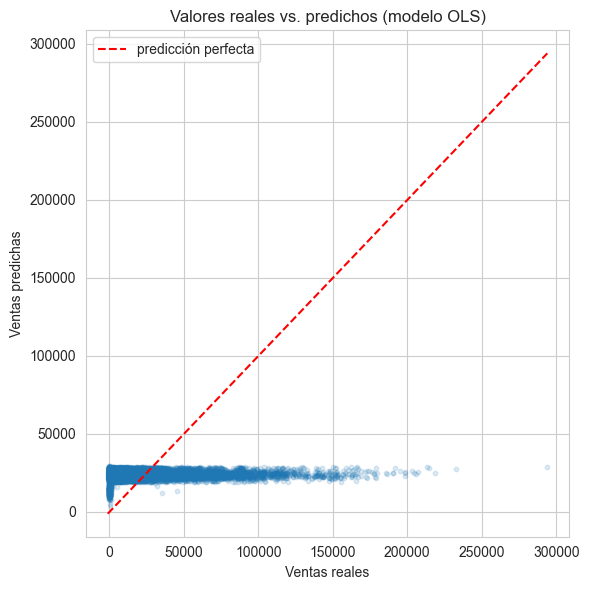

R² del modelo: 0.0073


In [40]:
# Predicciones vs valores reales
y_pred = X @ beta_hat_solve

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.15, s=10)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="predicción perfecta")
plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("Valores reales vs. predichos (modelo OLS)")
plt.legend()
plt.tight_layout()
plt.show()

r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)
print(f"R² del modelo: {r2:.4f}")

El $R^2$ es bajo — esperable, porque solo usamos tres variables macro y el dataset mezcla muchas tiendas y departamentos con niveles de venta muy distintos. El punto pedagógico no es la calidad predictiva sino verificar que el mecanismo matemático (álgebra → cálculo → OLS) funciona igual que en `sklearn`.

# Bloque 3: Probabilidad esencial

## Axiomas básicos

Para cualquier evento $A$:

1. $P(A) \geq 0$
2. $P(\Omega) = 1$ (el espacio muestral completo tiene probabilidad 1)
3. Si $A$ y $B$ son mutuamente excluyentes: $P(A \cup B) = P(A) + P(B)$

## Probabilidad condicional y Teorema de Bayes

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

El **Teorema de Bayes** permite "invertir" la condicional:

$$
P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}
$$

Veámoslo aplicado sobre el mismo dataset de ventas: ¿la probabilidad de que una semana sea de alta venta cambia si sabemos que es semana de feriado (`is_holiday`)?

In [41]:
# Definimos "alta venta" como estar por encima de la mediana
umbral = datos["weekly_sales"].median()
datos["alta_venta"] = datos["weekly_sales"] > umbral

tabla = pd.crosstab(datos["is_holiday"], datos["alta_venta"], normalize="index") * 100
tabla.columns = ["Venta baja (%)", "Venta alta (%)"]
tabla.index = ["No feriado", "Feriado"]
tabla.round(2)

,Venta baja (%),Venta alta (%)
No feriado,49.8,50.2
Feriado,100.0,0.0


In [42]:
p_alta = (datos["alta_venta"]).mean()
p_alta_dado_feriado = datos.loc[datos["is_holiday"], "alta_venta"].mean()
p_feriado = datos["is_holiday"].mean()

# Bayes: P(feriado | alta venta) = P(alta venta | feriado) * P(feriado) / P(alta venta)
p_feriado_dado_alta = (p_alta_dado_feriado * p_feriado) / p_alta

print(f"P(alta venta)                    = {p_alta:.4f}")
print(f"P(alta venta | feriado)          = {p_alta_dado_feriado:.4f}")
print(f"P(feriado | alta venta) [Bayes]  = {p_feriado_dado_alta:.4f}")
print(f"P(feriado) [base]                = {p_feriado:.4f}")

P(alta venta)                    = 0.5000
P(alta venta | feriado)          = 0.0000
P(feriado | alta venta) [Bayes]  = 0.0000
P(feriado) [base]                = 0.0039


Si $P(\text{feriado}\mid\text{alta venta}) > P(\text{feriado})$, saber que una semana tuvo alta venta hace *más probable* que haya sido feriado — es decir, la información sobre las ventas actualiza nuestra creencia sobre si fue feriado. Esta es la lógica de Bayes: actualizar probabilidades con nueva evidencia.

## Variables aleatorias y distribuciones clave

Una variable aleatoria puede ser:
- **Discreta**: toma valores contables (ej. número de feriados en un mes).
- **Continua**: toma cualquier valor en un rango (ej. `weekly_sales`, `temperature_c`).

Tres distribuciones son especialmente importantes para lo que sigue (inferencia sobre los coeficientes de OLS):

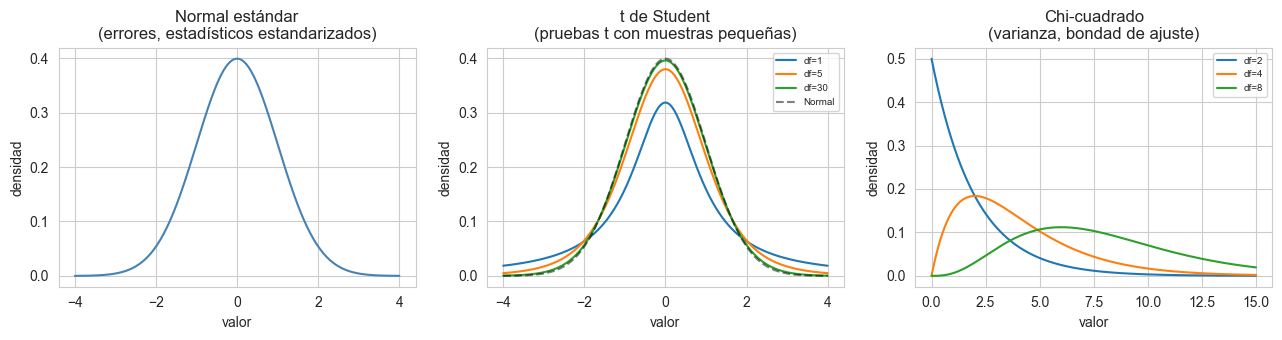

In [43]:
x_vals = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].plot(x_vals, stats.norm.pdf(x_vals), color="steelblue")
axes[0].set_title("Normal estándar\n(errores, estadísticos estandarizados)")

for df_ in [1, 5, 30]:
    axes[1].plot(x_vals, stats.t.pdf(x_vals, df=df_), label=f"df={df_}")
axes[1].plot(x_vals, stats.norm.pdf(x_vals), "k--", alpha=0.5, label="Normal")
axes[1].set_title("t de Student\n(pruebas t con muestras pequeñas)")
axes[1].legend(fontsize=7)

x_chi = np.linspace(0, 15, 300)
for df_ in [2, 4, 8]:
    axes[2].plot(x_chi, stats.chi2.pdf(x_chi, df=df_), label=f"df={df_}")
axes[2].set_title("Chi-cuadrado\n(varianza, bondad de ajuste)")
axes[2].legend(fontsize=7)

for ax in axes:
    ax.set_xlabel("valor"); ax.set_ylabel("densidad")

plt.tight_layout()
plt.show()

- La **Normal** aparece porque, bajo supuestos estándar, los errores de OLS y los coeficientes estimados se distribuyen (aproximadamente) normal.
- La **t de Student** aparece al estimar la varianza con una muestra finita (como haremos con los errores estándar de $\hat{\boldsymbol{\beta}}$): es una Normal "más ancha" que se acerca a la Normal cuando el tamaño de muestra crece.
- La **Chi-cuadrado** aparece en la estimación de la varianza de los errores y en pruebas de bondad de ajuste.

# Bloque 4: Inferencia esencial  

## Conceptos clave

### Valor esperado

El valor esperado de una variable aleatoria representa su valor promedio teórico
a largo plazo.

Para una variable aleatoria discreta:

$$
E[X] = \sum_x xP(X=x)
$$

El valor esperado no necesariamente tiene que ser un valor que la variable
pueda tomar.

Por ejemplo, si $X$ representa el número de accidentes de un asegurado,
su valor esperado podría ser $0.8$, aunque una persona no pueda tener
exactamente 0.8 accidentes.

#### Ejemplo

Supongamos la siguiente distribución:

| Número de accidentes | Probabilidad |
|---|---|
| 0 | 0.50 |
| 1 | 0.30 |
| 2 | 0.15 |
| 3 | 0.05 |

Entonces:

$$
E[X] =
0(0.50)+1(0.30)+2(0.15)+3(0.05)
$$

$$
E[X]=0.75
$$

In [44]:
import numpy as np
import pandas as pd

x = np.array([0, 1, 2, 3])
probabilidades = np.array([0.50, 0.30, 0.15, 0.05])

valor_esperado = np.sum(x * probabilidades)

print("Valor esperado:", valor_esperado)

Valor esperado: 0.75


## Varianza

La varianza mide la dispersión de una variable aleatoria respecto a su
valor esperado.

Se define como:

$$
Var(X)=E[(X-E[X])^2]
$$

También podemos utilizar:

$$
Var(X)=E[X^2]-(E[X])^2
$$

La desviación estándar corresponde a:

$$
\sigma = \sqrt{Var(X)}
$$

La varianza está expresada en unidades cuadradas, mientras que la desviación
estándar está expresada en las mismas unidades de la variable original.

In [45]:
EX = np.sum(x * probabilidades)

EX2 = np.sum((x**2) * probabilidades)

varianza = EX2 - EX**2

desviacion_estandar = np.sqrt(varianza)

print("Valor esperado:", EX)
print("Varianza:", varianza)
print("Desviación estándar:", desviacion_estandar)

Valor esperado: 0.75
Varianza: 0.7874999999999999
Desviación estándar: 0.8874119674649423


## Propiedades de la varianza

Para constantes $a$ y $b$:

$$
Var(aX+b)=a^2Var(X)
$$

En particular:

$$
Var(X+b)=Var(X)
$$

y:

$$
Var(aX)=a^2Var(X)
$$

## Distribuciones discretas y continuas

Una distribución de probabilidad describe cómo se distribuyen los posibles
valores de una variable aleatoria.

### Variables discretas

Una variable aleatoria discreta toma valores que pueden ser contados.

Ejemplos:

- número de accidentes;
- número de reclamaciones;
- número de clientes;
- número de errores.

Para una variable discreta podemos calcular directamente:

$$
P(X=x)
$$

y la suma de todas las probabilidades debe ser:

$$
\sum_x P(X=x)=1
$$

### Variables continuas

Una variable continua puede tomar cualquier valor dentro de un intervalo.

Ejemplos:

- tiempo de reparación;
- monto de una pérdida;
- duración de un proceso;
- peso.

En una variable continua:

$$
P(X=x)=0
$$

para un valor puntual.

Las probabilidades se calculan sobre intervalos:

$$
P(a<X<b)=\int_a^b f(x)\,dx
$$

donde $f(x)$ representa la función de densidad.

La diferencia fundamental es que en una variable discreta se asignan
probabilidades a valores específicos, mientras que en una variable continua
las probabilidades se obtienen mediante áreas sobre intervalos.

## Estimadores

Un estimador es una función de los datos muestrales que se utiliza para
aproximar un parámetro desconocido de la población.

Por ejemplo, para estimar la media poblacional $\mu$, podemos utilizar
la media muestral:

$$
\hat{\mu}=\bar{X}
$$

donde:

$$
\bar{X}=
\frac{1}{n}\sum_{i=1}^{n}X_i
$$

Es importante distinguir entre estimador y estimación.

El **estimador** es la regla o fórmula utilizada.

La **estimación** es el valor numérico obtenido después de observar los datos.

Por ejemplo:

$$
\hat{\mu}=\bar X
$$

es el estimador.

Si después de observar una muestra obtenemos:

$$
\bar{x}=72.5
$$

entonces 72.5 es la estimación puntual de $\mu$.

## Estimadores insesgados

Un estimador $\hat{\theta}$ es insesgado para un parámetro $\theta$ si:

$$
E[\hat{\theta}]=\theta
$$

El sesgo de un estimador se define como:

$$
Sesgo(\hat{\theta})
=
E[\hat{\theta}]-\theta
$$

Por lo tanto, un estimador es insesgado cuando:

$$
Sesgo(\hat{\theta})=0
$$

### Media muestral

La media muestral es un estimador insesgado de la media poblacional:

$$
E[\bar X]=\mu
$$

Por lo tanto:

$$
Sesgo(\bar X)=0
$$

## Varianza muestral

La varianza muestral:

$$
S^2=
\frac{1}{n-1}
\sum_{i=1}^{n}(X_i-\bar X)^2
$$

es un estimador insesgado de la varianza poblacional bajo los supuestos
habituales de una muestra aleatoria:

$$
E[S^2]=\sigma^2
$$

In [46]:
datos3 = np.array([10, 12, 15, 11, 14, 13, 16, 9, 12, 14])

varianza_n = np.var(datos3, ddof=0)

varianza_n_menos_1 = np.var(datos3, ddof=1)

print("Varianza usando n:", varianza_n)
print("Varianza usando n-1:", varianza_n_menos_1)

Varianza usando n: 4.4399999999999995
Varianza usando n-1: 4.933333333333334


El uso de $n-1$ en la varianza muestral proporciona un estimador insesgado
de la varianza poblacional bajo los supuestos habituales.

## Intervalos de confianza

Un intervalo de confianza permite construir un rango de valores plausibles
para un parámetro poblacional.

En términos generales:

$$
\text{Estimación}
\pm
\text{Valor crítico}
\times
\text{Error estándar}
$$

Para una media cuando la desviación estándar poblacional es desconocida,
podemos utilizar la distribución $t$:

$$
\bar X
\pm
t_{\alpha/2,n-1}
\frac{S}{\sqrt n}
$$

donde:

- $\bar X$ es la media muestral;
- $S$ es la desviación estándar muestral;
- $n$ es el tamaño de muestra;
- $t_{\alpha/2,n-1}$ es el valor crítico de la distribución t;
- $\alpha$ es el nivel de significancia.

In [47]:
from scipy import stats

datos4 = np.array([
    42, 38, 51, 47, 44,
    39, 55, 49, 46, 41,
    52, 45, 48, 43, 50
])

n = len(datos4)

media = np.mean(datos4)

s = np.std(datos4, ddof=1)

alpha = 0.05

valor_critico = stats.t.ppf(
    1 - alpha/2,
    df=n-1
)

error_estandar = s / np.sqrt(n)

margen = valor_critico * error_estandar

limite_inferior = media - margen
limite_superior = media + margen

print("Media:", media)
print("Error estándar:", error_estandar)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Media: 46.0
Error estándar: 1.2724180205607034
Límite inferior: 43.270934768035794
Límite superior: 48.729065231964206


In [48]:
intervalo = stats.t.interval(
    confidence=0.95,
    df=n-1,
    loc=media,
    scale=error_estandar
)

print("Intervalo de confianza:", intervalo)

Intervalo de confianza: (43.270934768035794, 48.729065231964206)


## Nivel de confianza y nivel de significancia

El nivel de confianza se representa mediante:

$$
1-\alpha
$$

donde $\alpha$ es el nivel de significancia.

Por ejemplo:

| Nivel de confianza | $\alpha$ |
|---|---:|
| 90% | 0.10 |
| 95% | 0.05 |
| 99% | 0.01 |

Un intervalo de confianza del 95% corresponde a:

$$
\alpha=1-0.95=0.05
$$

El nivel de significancia también se utiliza en las pruebas de hipótesis.

Es importante entender que un intervalo de confianza del 95% no significa
que exista una probabilidad del 95% de que un parámetro fijo esté dentro de
un intervalo particular. La interpretación frecuentista se refiere al
comportamiento del procedimiento al repetir el muestreo.

## Prueba de hipótesis

Una prueba de hipótesis permite evaluar una afirmación sobre un parámetro
poblacional utilizando información obtenida de una muestra.

Se establecen dos hipótesis:

### Hipótesis nula

$$
H_0
$$

Representa la afirmación de referencia.

### Hipótesis alternativa

$$
H_1
$$

Representa la afirmación que queremos contrastar frente a $H_0$.

Por ejemplo:

$$
H_0:\mu=50
$$

frente a:

$$
H_1:\mu\neq50
$$

Esta corresponde a una prueba bilateral.

La decisión se puede realizar utilizando el p-valor:

$$
p\text{-valor}<\alpha
\Rightarrow
\text{rechazar }H_0
$$

Mientras que:

$$
p\text{-valor}\geq\alpha
\Rightarrow
\text{no rechazar }H_0
$$

### Reglas de decisión para pruebas de hipótesis sobre la media

Sea la hipótesis nula:

$$
H_0:\mu=\mu_0
$$

y sea $\alpha$ el nivel de significancia.

#### Prueba bilateral

Cuando la hipótesis alternativa es:

$$
H_1:\mu\neq\mu_0
$$

La regla de decisión mediante el p-valor es:

$$
p\text{-valor}<\alpha
\quad\Rightarrow\quad
\text{Rechazar }H_0
$$

$$
p\text{-valor}\geq\alpha
\quad\Rightarrow\quad
\text{No rechazar }H_0
$$

Mediante el estadístico de prueba:

$$
|t|>t_{\alpha/2,n-1}
\quad\Rightarrow\quad
\text{Rechazar }H_0
$$


#### Prueba unilateral derecha

Cuando la hipótesis alternativa es:

$$
H_1:\mu>\mu_0
$$

La regla de decisión es:

$$
p\text{-valor}<\alpha
\quad\Rightarrow\quad
\text{Rechazar }H_0
$$

Mediante el estadístico de prueba:

$$
t>t_{\alpha,n-1}
\quad\Rightarrow\quad
\text{Rechazar }H_0
$$


#### Prueba unilateral izquierda

Cuando la hipótesis alternativa es:

$$
H_1:\mu<\mu_0
$$

La regla de decisión es:

$$
p\text{-valor}<\alpha
\quad\Rightarrow\quad
\text{Rechazar }H_0
$$

Mediante el estadístico de prueba:

$$
t<t_{\alpha,n-1}
\quad\Rightarrow\quad
\text{Rechazar }H_0
$$


#### Resumen

| Tipo de prueba | Hipótesis alternativa | Región de rechazo |
|:---|:---:|:---|
| Bilateral | $\mu\neq\mu_0$ | $|t|>t_{\alpha/2,n-1}$ |
| Unilateral derecha | $\mu>\mu_0$ | $t>t_{\alpha,n-1}$ |
| Unilateral izquierda | $\mu<\mu_0$ | $t<t_{\alpha,n-1}$ |

En todos los casos, utilizando el p-valor:

$$
\boxed{
p\text{-valor}<\alpha
\Rightarrow
\text{Rechazar }H_0
}
$$

$$
\boxed{
p\text{-valor}\geq\alpha
\Rightarrow
\text{No rechazar }H_0
}
$$

## 10. Prueba de normalidad

Las pruebas de normalidad permiten evaluar si los datos son compatibles
con el supuesto de normalidad.

Una prueba conocida es la prueba de **Shapiro-Wilk**.

Las hipótesis son:

$$
H_0:\text{los datos son compatibles con una distribución normal}
$$

$$
H_1:\text{los datos no son compatibles con una distribución normal}
$$

Utilizando un nivel de significancia $\alpha=0.05$:

- Si $p<0.05$, rechazamos $H_0$.
- Si $p\geq0.05$, no rechazamos $H_0$.

No rechazar $H_0$ no significa demostrar que los datos son normales.
Significa que no encontramos evidencia suficiente contra el supuesto
de normalidad.

In [49]:
datos5 = np.array([
    42, 38, 51, 47, 44,
    39, 55, 49, 46, 41,
    52, 45, 48, 43, 50
])

resultado_shapiro = stats.shapiro(datos5)

print("Estadístico:", resultado_shapiro.statistic)
print("p-valor:", resultado_shapiro.pvalue)
alpha = 0.05

if resultado_shapiro.pvalue < alpha:
    print("Se rechaza H0: evidencia contra la normalidad.")
else:
    print("No se rechaza H0: no hay evidencia suficiente contra la normalidad.")

Estadístico: 0.9851431846618652
p-valor: 0.9930816292762756
No se rechaza H0: no hay evidencia suficiente contra la normalidad.


## Prueba de diferencia de varianzas

Cuando queremos comparar la variabilidad de dos poblaciones podemos plantear:

$$
H_0:\sigma_1^2=\sigma_2^2
$$

frente a:

$$
H_1:\sigma_1^2\neq\sigma_2^2
$$

Una prueba ampliamente utilizada es la prueba de **Levene**.

La prueba de Levene permite evaluar si dos o más grupos presentan
varianzas iguales.

Para dos grupos:

$$
H_0:\sigma_1^2=\sigma_2^2
$$

$$
H_1:\sigma_1^2\neq\sigma_2^2
$$

Si el p-valor es menor que $\alpha$, rechazamos la igualdad de varianzas.

In [50]:
grupo_1 = np.array([
    42, 44, 43, 45, 41,
    46, 44, 43, 45, 42
])

grupo_2 = np.array([
    30, 55, 40, 65, 35,
    60, 45, 70, 32, 58
])

resultado_levene = stats.levene(
    grupo_1,
    grupo_2
)

print("Estadístico de Levene:", resultado_levene.statistic)
print("p-valor:", resultado_levene.pvalue)

alpha = 0.05

if resultado_levene.pvalue < alpha:
    print("Se rechaza H0: las varianzas son significativamente diferentes.")
else:
    print("No se rechaza H0: no hay evidencia suficiente de diferencia entre las varianzas.")

Estadístico de Levene: 37.55588235294117
p-valor: 8.675280751630627e-06
Se rechaza H0: las varianzas son significativamente diferentes.


## Errores tipo I y tipo II

Al realizar una prueba de hipótesis podemos cometer errores.

### Error tipo I

Se produce cuando rechazamos $H_0$ aunque $H_0$ sea verdadera.

Su probabilidad está relacionada con el nivel de significancia:

$$
P(\text{Error Tipo I})=\alpha
$$

Por ejemplo, si:

$$
\alpha=0.05
$$

el procedimiento se establece con un nivel de significancia del 5%.

## Error tipo II

Se produce cuando no rechazamos $H_0$ cuando $H_0$ es falsa.

Su probabilidad se representa normalmente mediante:

$$
\beta
$$

La potencia estadística es:

$$
Power=1-\beta
$$

### p-valor

El p-valor es una medida utilizada en las pruebas de hipótesis.

Bajo la hipótesis nula, representa la probabilidad de obtener un resultado
tan extremo o más extremo que el observado, de acuerdo con la distribución
del estadístico de prueba.

La regla de decisión habitual es:

$$
p<\alpha
\Rightarrow
\text{rechazar }H_0
$$

y:

$$
p\geq\alpha
\Rightarrow
\text{no rechazar }H_0
$$

Es importante no interpretar el p-valor como la probabilidad de que $H_0$
sea verdadera.



## Estimación puntual vs. intervalo de confianza

Un **estimador puntual** (como $\bar{x}$ para la media) da un solo número, pero no dice nada sobre qué tan confiable es. Un **intervalo de confianza (IC)** agrega esa incertidumbre:

$$
\bar{x} \pm t_{\alpha/2, \, n-1} \cdot \frac{s}{\sqrt{n}}
$$

donde $s$ es la desviación estándar muestral y $t_{\alpha/2, n-1}$ es el cuantil de la distribución t.

In [51]:
muestra = datos["weekly_sales"].sample(200, random_state=42)

media = muestra.mean()
error_estandar = muestra.std(ddof=1) / np.sqrt(len(muestra))
t_critico = stats.t.ppf(0.975, df=len(muestra) - 1)

ic_inferior = media - t_critico * error_estandar
ic_superior = media + t_critico * error_estandar

print(f"Media muestral: {media:.2f}")
print(f"Error estándar: {error_estandar:.2f}")
print(f"IC 95%: [{ic_inferior:.2f}, {ic_superior:.2f}]")

Media muestral: 23975.88
Error estándar: 2259.13
IC 95%: [19520.97, 28430.79]


**Interpretación correcta:** si repitiéramos este muestreo muchas veces y construyéramos un IC 95% cada vez, esperaríamos que el 95% de esos intervalos contengan la verdadera media poblacional. **No** significa que hay 95% de probabilidad de que la media verdadera esté en *este* intervalo específico (la media verdadera es fija, no aleatoria).

## Prueba de hipótesis: ¿las ventas en feriados son distintas?

$$
H_0: \mu_{\text{feriado}} = \mu_{\text{no feriado}} \qquad H_1: \mu_{\text{feriado}} \neq \mu_{\text{no feriado}}
$$

In [52]:
ventas_feriado = datos.loc[datos["is_holiday"], "weekly_sales"]
ventas_no_feriado = datos.loc[~datos["is_holiday"], "weekly_sales"]

t_stat, p_valor = stats.ttest_ind(ventas_feriado, ventas_no_feriado, equal_var=False)

print(f"Media en feriado:     {ventas_feriado.mean():.2f}")
print(f"Media en no feriado:  {ventas_no_feriado.mean():.2f}")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor-p: {p_valor:.6f}")

Media en feriado:     600.55
Media en no feriado:  23934.91
Estadístico t: -69.8121
Valor-p: 0.000000


**Interpretación correcta del valor-p:** es la probabilidad de observar una diferencia de medias tan extrema (o más) que la observada, **asumiendo que $H_0$ es verdadera** (que no hay diferencia real). No es la probabilidad de que $H_0$ sea verdadera, ni la probabilidad de "haberse equivocado" si se rechaza.

Con un umbral convencional de $\alpha = 0.05$: si el valor-p es menor que $\alpha$, se rechaza $H_0$ — hay evidencia de que las ventas en feriado difieren de las de no feriado.

# Bloque 5: Proyecto integrador mini

Ahora conectamos todo: tomamos el $\hat{\boldsymbol{\beta}}$ calculado en el Bloque 2 y le agregamos incertidumbre. La pregunta ya no es solo "¿cuál es el efecto estimado de cada variable?" sino "¿ese efecto es estadísticamente distinguible de cero?"

## Errores estándar de los coeficientes

Bajo los supuestos clásicos de OLS, la matriz de varianza-covarianza de $\hat{\boldsymbol{\beta}}$ es:

$$
\widehat{\text{Var}}(\hat{\boldsymbol{\beta}}) = \hat{\sigma}^2 (X^TX)^{-1}
\qquad \text{donde} \qquad
\hat{\sigma}^2 = \frac{\sum \hat{\epsilon}_i^2}{n - p}
$$

con $\hat{\epsilon}_i = y_i - \hat{y}_i$ los residuos, $n$ el número de observaciones y $p$ el número de parámetros (incluido el intercepto).

In [53]:
residuos = y - y_pred
n_obs, p_params = X.shape

sigma2_hat = np.sum(residuos**2) / (n_obs - p_params)
var_beta = sigma2_hat * np.linalg.inv(X.T @ X)
errores_estandar = np.sqrt(np.diag(var_beta))

t_stats = beta_hat_solve / errores_estandar
p_valores = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n_obs - p_params))

t_crit = stats.t.ppf(0.975, df=n_obs - p_params)
ic_inf = beta_hat_solve - t_crit * errores_estandar
ic_sup = beta_hat_solve + t_crit * errores_estandar

tabla_inferencia = pd.DataFrame({
    "coeficiente": nombres_coef,
    "beta_hat": beta_hat_solve,
    "error_std": errores_estandar,
    "t_stat": t_stats,
    "p_valor": p_valores,
    "IC_95_inf": ic_inf,
    "IC_95_sup": ic_sup
})
tabla_inferencia.round(4)

,coeficiente,beta_hat,error_std,t_stat,p_valor,IC_95_inf,IC_95_sup
0,intercepto,30729.1798,5135.1980,5.9840,0.0000,20663.2454,40795.1142
1,temperature_c,-96.4844,29.9207,-3.2247,0.0013,-155.1344,-37.8344
2,fuel_price_usd_per_l,-35848.8995,5010.0940,-7.1553,0.0000,-45669.6070,-26028.1920
3,unemployment,2661.4948,467.3036,5.6954,0.0000,1745.4937,3577.4959


## Validación contra `statsmodels`

`statsmodels` calcula exactamente esto con `.summary()`. Lo usamos para confirmar que el cálculo manual es correcto.

In [54]:
X_sm = sm.add_constant(X_raw)
modelo_sm = sm.OLS(y, X_sm).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     26.26
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           6.46e-17
Time:                        15:54:31   Log-Likelihood:            -1.2640e+05
No. Observations:               10774   AIC:                         2.528e+05
Df Residuals:                   10770   BIC:                         2.528e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.073e+04   5135.198      5.984      0.0

## Discusión guiada

Comparen la tabla calculada a mano con la salida de `statsmodels`:

- Los coeficientes (`beta_hat`) deben coincidir con `coef` en el resumen de `statsmodels`.
- Los errores estándar (`error_std`) deben coincidir con `std err`.
- Los estadísticos t y valores-p deben coincidir con `t` y `P>|t|`.
- Los intervalos de confianza deben coincidir con `[0.025, 0.975]`.

Para cada coeficiente: si el intervalo de confianza **no contiene el cero**, hay evidencia de que esa variable tiene un efecto real (distinto de cero) sobre las ventas semanales, al 95% de confianza — equivalente a que su valor-p sea menor a 0.05.

# Cierre y retroalimentación

## Síntesis del arco completo

1. **Álgebra lineal** (sesión anterior): representamos los datos como matrices y dedujimos que $\hat{\boldsymbol{\beta}} = (X^TX)^{-1}X^T\mathbf{y}$ resuelve el problema, apoyándonos en que $X^TX$ es simétrica y definida positiva.
2. **Cálculo** (este bloque): mostramos *por qué* esa fórmula es la solución — es el punto donde el gradiente de la función de pérdida se anula.
3. **Aplicación**: calculamos $\hat{\boldsymbol{\beta}}$ a mano sobre datos reales y confirmamos que coincide con `scikit-learn`.
4. **Probabilidad**: revisamos las herramientas (Bayes, distribuciones Normal/t/Chi-cuadrado) necesarias para hablar de incertidumbre.
5. **Inferencia**: le agregamos incertidumbre a $\hat{\boldsymbol{\beta}}$ — errores estándar, intervalos de confianza, pruebas de hipótesis — y lo validamos contra `statsmodels`.

## Brechas remanentes (material de refuerzo autodirigido)

Este nivelatorio comprimido no alcanza a cubrir todo. Para quienes quieran reforzar por su cuenta:

- **Regla de Cramer** y métodos alternativos para resolver sistemas lineales.
- **Integrales** (complemento natural de la derivada, útil para funciones de densidad de probabilidad).
- **Curtosis y asimetría** como medidas adicionales de forma de una distribución.
- **Combinatoria** (permutaciones, combinaciones), base de la probabilidad discreta más formal.

## Preguntas de cierre (para discusión)

1. ¿Por qué el gradiente de la función de pérdida se anula exactamente en el mínimo?
2. Si un coeficiente tiene un intervalo de confianza que sí contiene el cero, ¿qué se puede concluir sobre esa variable?
3. ¿Cuál es la interpretación *correcta* de un valor-p de 0.03 en una prueba de hipótesis?
4. ¿Por qué usamos la distribución t (y no la Normal) para construir el intervalo de confianza de los coeficientes de OLS?
